# *Breast Cancer Detection Using Deep Learning (Fuzzy)*

# 01 - Data Exploration

Purpose:
- Load raw breast thermogram images
- Visualize sample images
- Inspect image size, channels and intensity range
- Verify dataset structure

Dataset(s):
- DMR-IR

In [1]:
import gc
import cv2
import math
import sys, os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from scipy.signal import find_peaks # to calculate histogram peaks
from skimage.measure import regionprops # Centroid Knowledge(CS)
from skimage.filters import threshold_otsu
from scipy.ndimage import label, find_objects
from skimage.morphology import disk, reconstruction

In [2]:
sys.path.append(os.path.abspath(".."))

In [3]:
from src.preprocessing import DatasetPlot
from experiments.exp_preprocessing import PreprocessingPipeline
# from src.sch_cs import compute_count_threshold, compute_initial_threshold
from src.utils import base_path, bcd_dataset, thiago_dataset, breast_cancer_dataset, dmr_ir_diff_view_dataset, breast_thermography_dataset, config_1

## 1. Thiago Alves Elias da Silva

### Healthy

In [ ]:
thiago_healthy_data = base_path + thiago_dataset["training"] + thiago_dataset["healthy"]

plotter1 = DatasetPlot(cols=3, path=thiago_healthy_data)
plotter1.main()

### Diseased

In [ ]:
thiago_diseased_data = base_path + thiago_dataset["training"] + thiago_dataset["diseased"]

plotter2 = DatasetPlot(cols=3, path=thiago_diseased_data)
plotter2.main()

### Matrix

In [ ]:
matrix = np.loadtxt(base_path + thiago_dataset["training"] + thiago_dataset["mat_diseased"], dtype=np.float32)
print(matrix.shape)
print(matrix.max(), matrix.min())

In [ ]:
plt.imshow(matrix, cmap="inferno")
plt.colorbar()
plt.show()

### Step A - Generate Suspicious Region (SCH-CS stage)

In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans

def sch_cs_segmentation(img):
    # Flatten image for clustering
    pixel_values = img.reshape((-1, 1))
    
    kmeans = KMeans(n_clusters=2)
    kmeans.fit(pixel_values)
    
    segmented = kmeans.labels_.reshape(img.shape)
    
    # Select brighter cluster
    cluster_means = [img[segmented == i].mean() for i in range(2)]
    suspicious_cluster = np.argmax(cluster_means)
    
    mask = (segmented == suspicious_cluster).astype(np.uint8)
    
    return mask


In [ ]:
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

STEP B — Convert Mask to Initial Level Set

In [ ]:
from scipy.ndimage import distance_transform_edt

def mask_to_sdf(mask):
    inside = distance_transform_edt(mask)
    outside = distance_transform_edt(1-mask)
    sdf = inside - outside
    return sdf

In [ ]:
phi = mask_to_sdf(mask)

STEP C — Apply Level Set Refinement

In [ ]:
from skimage.segmentation import morphological_chan_vese

ls = morphological_chan_vese(img,
                             num_iter=100,
                             init_level_set=mask)

## 2. DMR-IR Different View

### Diseased

In [ ]:
plotter3 = DatasetPlot(3, base_path + dmr_ir_diff_view_dataset["sick"])
plotter3.main()

### Healthy

In [ ]:
plotter4 = DatasetPlot(3, base_path + dmr_ir_diff_view_dataset["healthy"])
plotter4.main()

## 3. Breast Cancer Dataset

### Diseased

In [ ]:
plotter5 = DatasetPlot(3, base_path + breast_cancer_dataset["sick"])
plotter5.main()

### Healthy

In [ ]:
plotter6 = DatasetPlot(3, base_path + breast_cancer_dataset["healthy"])
plotter6.main()

## 4. Breast Thermography

### Diseased

In [ ]:
plotter7 = DatasetPlot(3, base_path + breast_thermography_dataset["sick"])
plotter7.main()

### Healthy

In [ ]:
plotter8 = DatasetPlot(3, base_path + breast_thermography_dataset["healthy"])
plotter8.main()

## 5. BCD Dataset

In [ ]:
bcd_dataset = {
    "sick": r"\BCD_Dataset\Sick",
    "healthy": r"\BCD_Dataset\normal",
    "unknown": r"\BCD_Dataset\Unknown_class"
}
print(os.path.exists(base_path + bcd_dataset["sick"]))

### Diseased

In [ ]:
plotter9 = DatasetPlot(3, base_path + bcd_dataset["sick"])
plotter9.main()

### Healthy

In [ ]:
plotter10 = DatasetPlot(3, base_path + bcd_dataset["healthy"])
plotter10.main()

### Preprocessing - Breast Region Extraction

In [ ]:
class ImageProcessor:
    def __init__(self):
        pass

    def _load_grayscale(self, image_path):
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Could not load image from {image_path}")
        return img

    def visualize_original_processed_and_histogram(self, original_img, processed_img, original_title, processed_title, histogram_title):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Original Image Plot
        axes[0].imshow(original_img, cmap='gray')
        axes[0].set_title(original_title)
        axes[0].axis('off')

        # Processed Image Plot
        axes[1].imshow(processed_img, cmap='gray')
        axes[1].set_title(processed_title)
        axes[1].axis('off')

        # Histogram Plot of Processed Image
        axes[2].hist(processed_img.ravel(), 256, range=[0, 256], color='gray')
        axes[2].set_title(histogram_title)
        axes[2].set_xlabel('Pixel Intensity')
        axes[2].set_ylabel('Frequency')

        plt.tight_layout()
        plt.show()

    def remove_background_soft(self, img):
        # Normalize image (important)
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

        # Very low threshold just to remove pure black borders
        _, thresh = cv2.threshold(img, 5, 255, cv2.THRESH_BINARY)

        # Morphological closing to fill tiny holes
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

        # Apply mask
        result = cv2.bitwise_and(img, mask)

        return result

    def remove_background_otsu(self, img):
        # otsu threshold
        _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # morphological smoothing
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

        # finding largest component
        contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contours = [c for c in contours if cv2.contourArea(c) > 5000]
        if not contours:
            return np.zeros_like(img) # Return a black image if no significant contour found

        # Sort contours by area in descending order
        contours = sorted(contours, key=cv2.contourArea, reverse=True)

        mask = np.zeros_like(img)
        h, w = img.shape

        # Draw the top 2 largest contours onto the mask
        # This addresses the case where breast might be split into two main components
        for i, cnt in enumerate(contours):
            if i >= 2: # Only consider the top 2 largest contours
                break
            cv2.drawContours(mask, [cnt], -1, 255, -1)

        # Remove top 15% rows from the mask
        # Applied to the mask AFTER drawing the contours
        mask[:int(0.15*h), :] = 0

        # Applying the mask to the original image
        breast = cv2.bitwise_and(img, mask)

        return breast

    def gray_level_reconstruction(self, img):

        # Step 1: Otsu threshold
        thresh_val = threshold_otsu(img)
        binary = img > thresh_val

        # Step 2: Erode image to create marker
        kernel = disk(5)
        eroded = cv2.erode(img, np.ones((5,5), np.uint8))

        # Step 3: Reconstruction
        reconstructed = reconstruction(
            eroded,
            img,
            method='dilation'
        )

        # Convert to uint8
        reconstructed = np.uint8(reconstructed)

        return reconstructed

#### Process Single or Multiple Images

Use the `image_selection` variable to choose which images to process.

*   To process specific images, provide a list of their 0-based indices (e.g., `[0, 2, 4]`).
*   To process all images, set `image_selection = 'all'`.

In [ ]:
# Initialize the image processor
processor = ImageProcessor()

# Get all image files from the directory
image_files = [
    f for f in os.listdir(base_path + bcd_dataset["sick"])
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]
image_files.sort() # Sort to ensure consistent order

# --- USER SELECTION ---
image_selection = 'all' # @param ['all', '[0]', '[0,1]', '[0,1,2]']

# Determine which images to process based on selection
if image_selection == 'all':
    images_to_process = image_files
elif isinstance(image_selection, list):
    # Filter image_files based on provided indices
    images_to_process = [image_files[i] for i in image_selection if i < len(image_files)]
else:
    print("Invalid image_selection. Please use 'all' or a list of indices.")
    images_to_process = []

print(f"Processing {len(images_to_process)} image(s).")

# Process and visualize each selected image
for filename in images_to_process:
    img_path = os.path.join(base_path + bcd_dataset["sick"], filename)

    try:
        # Load the original image
        original_img = processor._load_grayscale(img_path)

        # Process the image (remove background)
        processed_img = processor.remove_background_soft(original_img)
        reconstructed_img = processor.gray_level_reconstruction(processed_img)

        # Visualize the comparison with histogram
        print(f"Displaying: {filename}")
        processor.visualize_original_processed_and_histogram(
            original_img, reconstructed_img,
            f"Original: {filename}",
            f"Background Removed: {filename}",
            f"Histogram of Processed: {filename}"
        )
    except ValueError as e:
        print(f"Error processing {filename}: {e}")
    except Exception as e:
        print(f"An unexpected error occurred with {filename}: {e}")

print("Image processing complete.")

### **SCH Process**
*Smaller-peaks Corresponding to the High-intensity-pixels of Suspicious Regions*

In [ ]:
# Step-1 Compute Histogram
hist = cv2.calcHist([reconstructed_img], [0], None, [256], [0,256])
hist = hist.flatten()

# Step-2 Histogram Peaks Detection
peaks, _ = find_peaks(hist)

# Step-3 Threshold ρ Count Computation
rho = np.max(hist) * 0.03  # 10% of max as initial estimate

# Step-4 Smaller Peaks Selection
selected_peaks = [p for p in peaks if hist[p] < rho and p > 80]

# Step-5 Threshold Computation
A = np.array(selected_peaks)

if len(A) > 0:
    t_star = np.mean(A) - np.std(A)
else:
    t_star = np.mean(reconstructed_img)

mean_img = np.mean(reconstructed_img)

if t_star < mean_img:
    th = mean_img
else:
    th = t_star

# Step-6 Applying Threshold
sr_binary = reconstructed_img > th

# Visuzalizing
plt.imshow(sr_binary, cmap='gray')
plt.title("SCH Output")
plt.show()

> The SCH (Smaller-peaks Corresponding to the High-intensity-pixels and the Centroid-knowledge of Suspicious Regions) process is a method to identify suspicious regions in an image. Here's a breakdown of what has been done so far:

Compute Histogram: First, we calculated a histogram of the processed image (reconstructed_img). Think of a histogram as a bar chart that shows how many pixels in the image have each possible brightness level (from 0 for black to 255 for white).

Histogram Peaks Detection: Next, we identified the 'peaks' in this histogram. These peaks represent the most common brightness levels in the image.

Threshold ρ (Rho) Calculation: We then calculated a value called rho, which is 10% of the highest bar in the histogram. This rho acts as a preliminary filter.

Smaller Peaks Selection: We then looked for peaks that were 'smaller' (meaning their bar in the histogram was less than rho) and also had a brightness level above 80. These are the selected_peaks which are likely to correspond to the darker, more suspicious regions.

Final Threshold Computation: Using these selected_peaks, we calculated a final threshold (th). This involves taking the average of these selected peaks and subtracting their variation (standard deviation). The goal is to find a brightness level that effectively separates the suspicious regions from the rest of the image.

Applying Threshold: Finally, we applied this th threshold to the image. All pixels brighter than th are turned white, and all pixels darker than th are turned black. This creates a binary image (sr_binary) where the white areas are the potential 'suspicious regions' identified by the SCH process.

In essence, the process is trying to find and isolate regions that are darker than the main breast tissue by analyzing the distribution of pixel brightness.

### **CS Process**
*Centroid-knowledge process for Suspicious Regions*

In [ ]:
def adjust_centroid_inside(region, binary_image):
    """
    Algorithm 1 from the paper: if centroid lies outside the region,
    place it inside using bounding‑box corner distances.
    """
    # Get bounding box of the region
    minr, minc, maxr, maxc = region.bbox
    # Original centroid (from regionprops)
    y_c, x_c = int(region.centroid[0]), int(region.centroid[1])

    # If centroid is already inside, return it
    if binary_image[y_c, x_c] != 0:
        return (x_c, y_c)

    # Four corners of the bounding box
    corners = [(minc, minr), (maxc-1, minr), (minc, maxr-1), (maxc-1, maxr-1)]

    # Compute half‑distance from original centroid to each corner
    distances = []
    for (cx, cy) in corners:
        d = np.hypot(x_c - cx, y_c - cy) / 2.0
        distances.append((d, (cx, cy)))

    # Choose the corner with smallest half‑distance
    _, best_corner = min(distances, key=lambda x: x[0])
    return best_corner

def cs_process(sr_binary, epsilon=35):
    """
    sr_binary : binary image (0 or 255) from SCH
    returns   : binary image with only the suspicious regions
    """
    # Ensure binary is 0/1
    if sr_binary.dtype != bool:
        sr_binary = sr_binary > 0

    # Label connected components
    label_img = label(sr_binary, connectivity=2)
    regions = regionprops(label_img)

    if not regions:
        return np.zeros_like(sr_binary, dtype=np.uint8)

    # Prepare list of (label, centroid_x, centroid_y)
    # Also store the region object for later use
    comp_list = []
    for reg in regions:
        # Get centroid (regionprops returns (row, col) = (y, x))
        x, y = int(reg.centroid[1]), int(reg.centroid[0])
        # Optional: adjust if outside
        if sr_binary[y, x] == 0:
            x, y = adjust_centroid_inside(reg, sr_binary)
        comp_list.append({
            'label': reg.label,
            'x': x,
            'y': y,
            'region': reg
        })

    # Iterative elimination
    while True:
        if len(comp_list) == 0:
            break

        # 1. Average X of all current components
        avg_x = np.mean([c['x'] for c in comp_list])

        # 2. Remove those with X < avg_x (left side)
        comp_list = [c for c in comp_list if c['x'] >= avg_x]
        if len(comp_list) == 0:
            break

        # 3. New average X of remaining
        avg_x = np.mean([c['x'] for c in comp_list])

        # 4. Remove those with X > avg_x (right side)
        comp_list = [c for c in comp_list if c['x'] <= avg_x]
        if len(comp_list) == 0:
            break

        # 5. Final average X for this iteration
        avg_x = np.mean([c['x'] for c in comp_list])

        # 6. Check condition: all |X - avg_x| <= epsilon ?
        if all(abs(c['x'] - avg_x) <= epsilon for c in comp_list):
            break
        # otherwise continue loop (repeat elimination)

    # Build output binary image with only the kept components
    output = np.zeros_like(sr_binary, dtype=np.uint8)
    for comp in comp_list:
        # Extract the region mask using its label
        mask = (label_img == comp['label'])
        output[mask] = 255

    return output

# Usage after your SCH step:
sr_binary = (reconstructed_img > th).astype(np.uint8) * 255
sr_final = cs_process(sr_binary)

plt.imshow(sr_final, cmap='gray')
plt.title("Final SRs after CS")
plt.show()

*another method*

In [ ]:
import numpy as np
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt

# Assuming sr_binary from the SCH process (cell Ts0T2RaXiYHm) is a boolean array

print("\n--- Centroid-knowledge (CS) Process: Region Analysis and Filtering ---")

# Perform connected component analysis
labeled = label(sr_binary)
regions = regionprops(labeled)

print(f"Initial number of regions detected: {len(regions)}")

# Initialize an empty binary mask with the same shape and data type as sr_binary
cs_output_mask = np.zeros_like(sr_binary, dtype=bool)

h = sr_binary.shape[0] # Image height

# Filtering parameters
max_area = 10000  # Maximum allowed area for a region
min_row = h * 0.15  # Minimum row threshold for centroid (to exclude neck area, e.g., top 15%)
max_row = h * 0.85  # Maximum row threshold for centroid (to exclude stomach area, e.g., bottom 15%)

print(f"Filtering Parameters: ")
print(f"  Max Area: {max_area}")
print(f"  Min Row (from top): {min_row:.2f} pixels (15% of {h})")
print(f"  Max Row (from top): {max_row:.2f} pixels (85% of {h})")

filtered_regions_count = 0
# Iterate through each region and apply filtering criteria
for region in regions:
    # Area Filtering: Skip this region if its area exceeds the maximum allowed
    if region.area > max_area:
        # print(f"  Region {region.label}: Removed (Area {region.area} > {max_area})")
        continue

    # Centroid Location Filtering (Neck and Stomach):
    # Get the centroid coordinates (row, column)
    r, c = region.centroid

    # Skip if centroid is in the neck area (too high up)
    if r < min_row:
        # print(f"  Region {region.label}: Removed (Centroid row {r:.2f} < {min_row:.2f})")
        continue
    # Skip if centroid is in the stomach area (too low down)
    if r > max_row:
        # print(f"  Region {region.label}: Removed (Centroid row {r:.2f} > {max_row:.2f})")
        continue

    # If all filtering conditions are met, add the region to the output mask
    cs_output_mask[region.slice] |= region.image
    filtered_regions_count += 1

print(f"Number of regions after filtering: {filtered_regions_count}")

# Update sr_binary with the new filtered mask
sr_binary = cs_output_mask

# Visualize the resulting sr_binary mask
plt.figure(figsize=(8, 6))
plt.imshow(sr_binary, cmap='gray')
plt.title("CS Output (Filtered Regions)")
plt.axis('off')
plt.show()

print("Centroid-knowledge (CS) process complete, sr_binary updated and visualized.")


## 5. BCD Dataset - 2

[Pipeline] Found 100
[Pipeline] Running single image processing

[Pipeline] Processing: T0138.2.1.D.2013-09-06.02.jpg
[Log] ImageProcessor: Loaded image ..\data\raw\BCD_Dataset\Sick\T0138.2.1.D.2013-09-06.02.jpg in grayscale.
[Log] ImageProcessor: Image is already grayscale.
[Otsu] Automatically selected threshold value: 109.0
[Otsu] Found 41 components — kept only the largest.


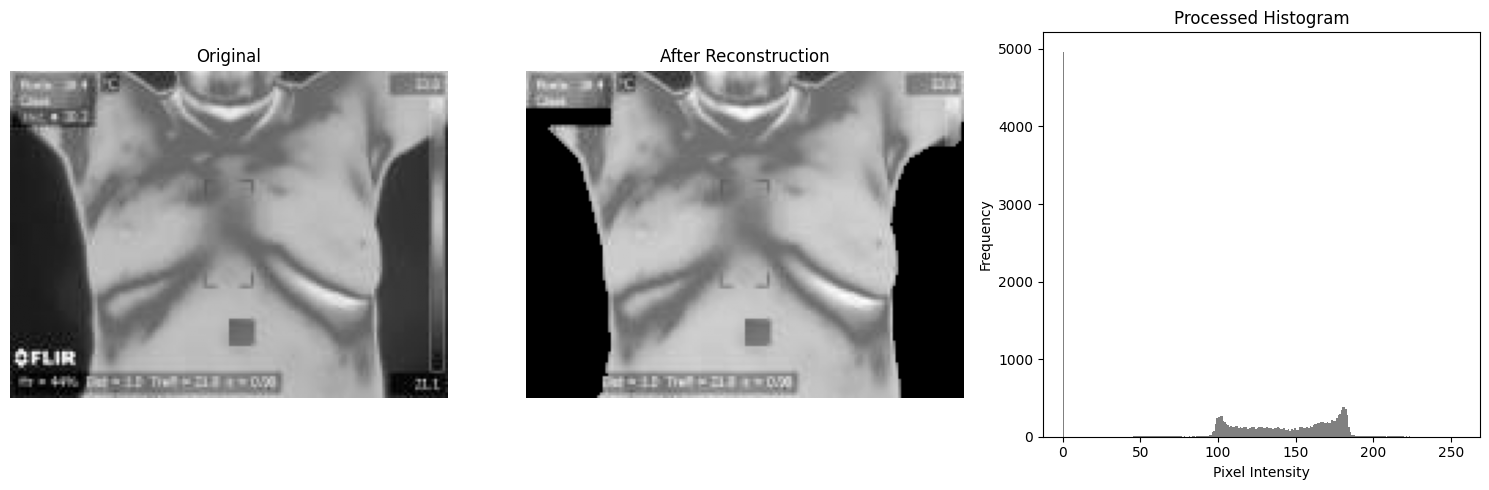

[Log] ImageProcessor: Displayed original, processed image and its histogram for 'Original'.


In [4]:
pipeline = PreprocessingPipeline(config_1)

results = pipeline.run()

### OTSU Thresholding

In [ ]:
bg_removed, breast_mask = remove_background(final_grayscale_img)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Section II-A Preprocessing Pipeline", fontsize=14, fontweight='bold')

axes[0].imshow(final_grayscale_img, cmap='gray')
axes[0].set_title("(a) Input Grayscale TBI")
axes[0].axis('off')

axes[1].imshow(breast_mask * 255, cmap='gray')
axes[1].set_title("(b) Otsu Binary Mask")
axes[1].axis('off')

axes[2].imshow(bg_removed, cmap='gray')
axes[2].set_title("(c) After Background Removal")
axes[2].axis('off')

plt.tight_layout()

### Gray-level morphological reconstruction

In [ ]:
pb = gray_level_reconstruction(bg_removed, final_grayscale_img)
print("[Step 2] Gray-level reconstruction done. (= I_c = p_b)")

fig, axes = plt.subplots(1, 1, figsize=(18, 5))
fig.suptitle("Section II-A Preprocessing", fontsize=14, fontweight='bold')

axes.imshow(pb, cmap='gray')
axes.set_title("(d) After Gray-level Reconstruction\n(= p_b, ready for SCH-CS)")
axes.axis('off')

plt.tight_layout()

### SCH-CS

In [ ]:
# Step 1 - Count Threshold(rho)
step1 = compute_count_threshold(pb, plot_histogram=True)
print("\n[Done] step1 results ready to pass into Step 2.")

# Step 2 - Initial Threshold t*
# step2 = compute_initial_threshold(step1, plot=True)
# print("\n[Done] step2 results ready to pass into Step 3.")

# After Every Run

In [ ]:
# del df
gc.collect()